In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 设置中文显示（如果乱码，可以注释掉或改成英文字体）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 1. 加载小样本数据
df = pd.read_csv('/Users/zibinzhao/Desktop/Journal paper/fault_diagnosis_balanced.csv')  
print(f"数据集形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(df)

数据集形状: (1350000, 6)
列名: ['acc1', 'acc2', 'acc3', 'acc4', 'Torque', 'Label']
               acc1       acc2       acc3       acc4  Torque  Label
0        -29.230760  12.684816   2.158651  11.102118    0.12      0
1         46.543896  -7.884743   8.650433  18.654587    0.12      0
2        -75.419160  67.644740  -4.374711 -14.652700    0.12      0
3         70.899570  -7.555561 -12.199799   5.188443    0.12      0
4         61.169064 -50.635780   6.426600 -12.344208    0.12      0
...             ...        ...        ...        ...     ...    ...
1349995   37.177315  21.830006  23.375338 -31.540846    1.31      1
1349996  -40.702800  58.235077 -15.687823  14.155883    1.31      1
1349997 -116.735750  71.538450  17.510923  -8.816381    1.31      1
1349998    4.721499  83.787420 -13.531794  -3.641331    1.31      1
1349999   93.231170  13.424658  -7.728721 -29.849981    1.31      1

[1350000 rows x 6 columns]


In [5]:
# 2. 检查缺失值
print(f"\n缺失值统计:\n{df.isnull().sum()}")



缺失值统计:
acc1      0
acc2      0
acc3      0
acc4      0
Torque    0
Label     0
dtype: int64


In [6]:
# 3. 数据类型与内存占用
print(f"\n数据信息:")
df.info()



数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350000 entries, 0 to 1349999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   acc1    1350000 non-null  float64
 1   acc2    1350000 non-null  float64
 2   acc3    1350000 non-null  float64
 3   acc4    1350000 non-null  float64
 4   Torque  1350000 non-null  float64
 5   Label   1350000 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 61.8 MB


In [7]:
# 4. 描述性统计
print("\n加速度计描述性统计:")
print(df[['acc1', 'acc2', 'acc3', 'acc4']].describe())


加速度计描述性统计:
               acc1          acc2          acc3          acc4
count  1.350000e+06  1.350000e+06  1.350000e+06  1.350000e+06
mean  -3.900150e-03  6.199234e-03  4.105869e-02 -2.656693e-02
std    5.948469e+01  4.491606e+01  3.462381e+01  2.955660e+01
min   -3.438881e+02 -5.026486e+02 -5.028195e+02 -5.027655e+02
25%   -3.888993e+01 -2.749593e+01 -1.306441e+01 -1.186809e+01
50%    8.535804e-01 -1.863651e-02 -1.144179e+00  3.755866e-01
75%    4.012535e+01  2.715623e+01  1.082596e+01  1.235189e+01
max    2.474107e+02  5.027984e+02  5.028314e+02  5.029932e+02


## 目标变量分布

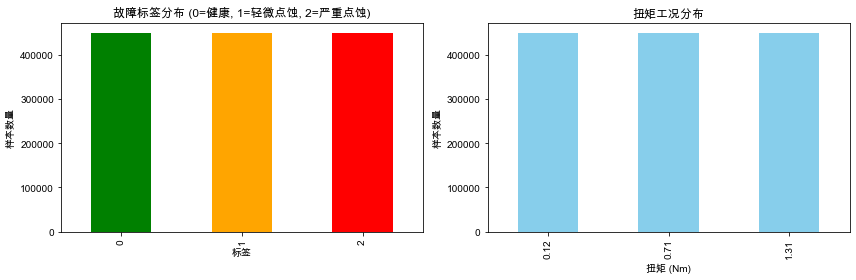

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 标签分布
df['Label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('故障标签分布 (0=健康, 1=轻微点蚀, 2=严重点蚀)')
axes[0].set_xlabel('标签')
axes[0].set_ylabel('样本数量')

# 扭矩分布
df['Torque'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('扭矩工况分布')
axes[1].set_xlabel('扭矩 (Nm)')
axes[1].set_ylabel('样本数量')

plt.tight_layout()
plt.show()

1. 类别情况：
- 健康状态映射：0->健康, 1->轻微点蚀, 2->严重点蚀


fault_mapping = {
    'Healthy': 0,
    'Mild_Micropitting': 1,
    'Severe_Pitting': 2
}


2. 扭矩（Torque）：齿轮磨损越严重，扭矩变大，且变化频率不稳定。

## 时域信号可视化

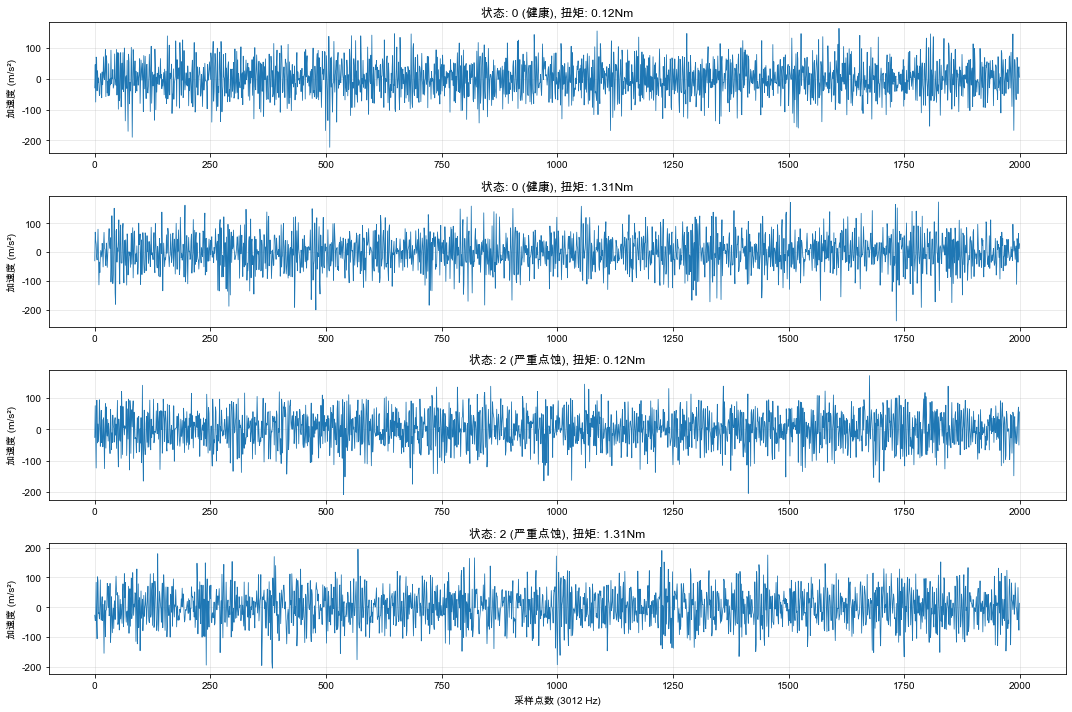

In [10]:
# 选取四种典型组合：健康+低扭矩、健康+高扭矩、严重点蚀+低扭矩、严重点蚀+高扭矩
sample_conditions = [
    (0, 0.12),  # 健康 + 0.12Nm
    (0, 1.31),  # 健康 + 1.31Nm
    (2, 0.12),  # 严重 + 0.12Nm
    (2, 1.31)   # 严重 + 1.31Nm
]

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
plot_length = 2000  # 显示前2000个点（约0.66秒）

for idx, (label, torque) in enumerate(sample_conditions):
    # 筛选该工况组合的前一段数据
    subset = df[(df['Label'] == label) & (df['Torque'] == torque)]
    if len(subset) > plot_length:
        signal = subset['acc1'].iloc[:plot_length].values
        axes[idx].plot(signal, linewidth=0.8)
        axes[idx].set_title(f'状态: {label} ({"健康" if label==0 else "严重点蚀"}), 扭矩: {torque}Nm')
        axes[idx].set_ylabel('加速度 (m/s²)')
        axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('采样点数 (3012 Hz)')
plt.tight_layout()
plt.show()

- 健康信号通常呈现规则的周期正弦波。
- 故障信号（点蚀）会出现冲击脉冲或幅值调制现象，波形杂乱。

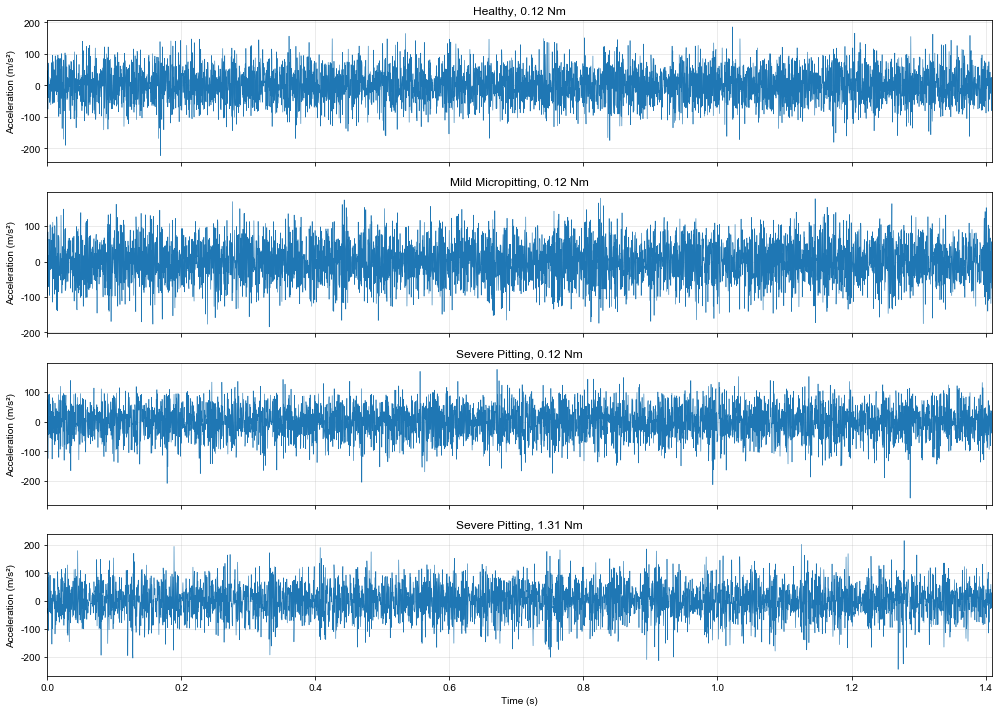

In [26]:
# 1. 设置参数
fs = 3012  # 采样频率 3012 Hz
duration = 1.41  # 持续时间（秒），可根据需要调整
n_samples = int(fs * duration)  # 需要提取的样本点数

# 2. 定义要提取的四种工况组合
# (标签, 扭矩, 子图标题)
conditions = [
    (0, 0.12, 'Healthy, 0.12 Nm'),      # 健康，低扭矩
    (1, 0.12, 'Mild Micropitting, 0.12 Nm'), # 轻微点蚀，低扭矩
    (2, 0.12, 'Severe Pitting, 0.12 Nm'),    # 严重点蚀，低扭矩
    (2, 1.31, 'Severe Pitting, 1.31 Nm')     # 严重点蚀，高扭矩
]

# 3. 创建图形
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, (label, torque, title) in zip(axes, conditions):
    # 从数据集中筛选出符合当前工况组合的数据
    subset = df[(df['Label'] == label) & (df['Torque'] == torque)]
    
    # 检查是否有足够的数据
    if len(subset) < n_samples:
        print(f"警告: 工况 {title} 的数据不足 {n_samples} 个点，仅有 {len(subset)} 个点。将使用全部数据。")
        signal = subset['acc1'].values  # 使用全部数据
    else:
        # 取该工况组合下的前 n_samples 个连续点（保留时序）
        signal = subset['acc1'].iloc[:n_samples].values
    
    # 生成对应的时间轴
    time_axis = np.arange(len(signal)) / fs
    
    # 绘制时域信号
    ax.plot(time_axis, signal, linewidth=0.6)
    ax.set_ylabel('Acceleration (m/s²)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(time_axis[0], time_axis[-1])

# 设置共同的X轴标签
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

分别展示健康（Healthy）、轻微点蚀（Mild Micropitting） 和严重点蚀（Severe Pitting） 状态下的时域信号，并特别对比了严重点蚀在低扭矩和高扭矩两种工况下的表现差异

## 频域分析（FFT频谱）

- 按工况分组计算平均频谱。

In [11]:
# 定义一个计算FFT幅值谱的函数
def compute_spectrum(signal, fs=3012):
    n = len(signal)
    # 加汉宁窗减少频谱泄漏
    window = np.hanning(n)
    yf = fft(signal * window)
    xf = fftfreq(n, 1/fs)[:n//2]
    magnitude = 2.0/n * np.abs(yf[:n//2])
    return xf, magnitude

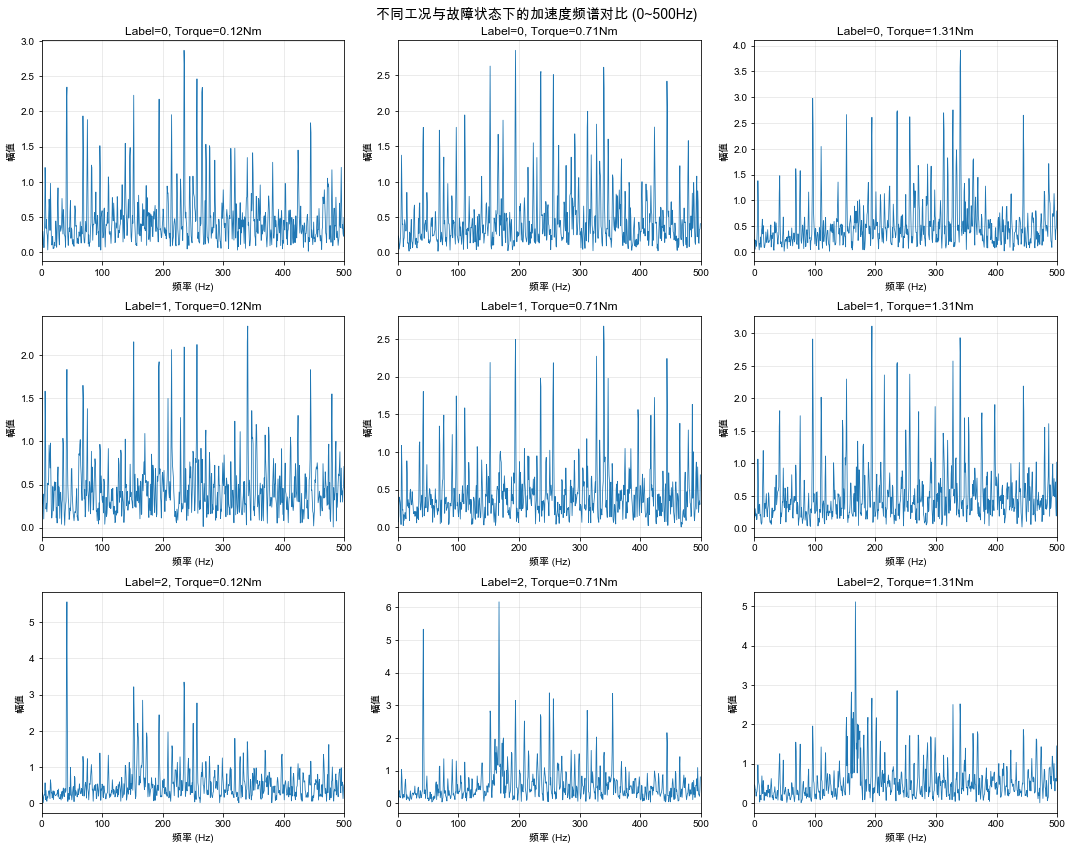

In [22]:
# 按 (Label, Torque) 分组，取每组前 4096 个点做FFT（保证频率分辨率）
grouped = df.groupby(['Label', 'Torque'])
fs = 3012
fft_results = {}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, ((label, torque), group) in enumerate(grouped):
    # 取该组连续的前4096个点（如果不够，跳过）
    if len(group) < 4096:
        continue
    signal = group['acc1'].iloc[:4096].values
    freqs, mags = compute_spectrum(signal, fs)
    
    # 只关注 0~500 Hz 范围（齿轮啮合频率通常在此区间）
    mask = freqs <= 500
    ax = axes[idx]
    ax.plot(freqs[mask], mags[mask], linewidth=0.8)
    ax.set_title(f'Label={label}, Torque={torque}Nm')
    ax.set_xlabel('频率 (Hz)')
    ax.set_ylabel('幅值')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 500)

# 隐藏多余的子图
for j in range(idx+1, 9):
    axes[j].axis('off')

plt.suptitle('不同工况与故障状态下的加速度频谱对比 (0~500Hz)', fontsize=14)
plt.tight_layout()
plt.show()

- 健康的齿轮频谱通常峰值单一，集中在转频及其倍频。
- 点蚀故障会在啮合频率周围产生边频带（调制现象），频谱变得“胖”而杂乱。

## 统计特征对比

提取时域统计特征（均值、标准差、峰度、偏度），看它们能否有效区分不同故障。

In [15]:
# 计算额外的统计特征
stats_df = df.groupby('Label').agg({
    'acc1': ['mean', 'std', 'skew', kurtosis],
    'acc2': ['mean', 'std', 'skew', kurtosis],
    'acc3': ['mean', 'std', 'skew', kurtosis],
    'acc4': ['mean', 'std', 'skew', kurtosis]
})
print("按标签分组的统计特征:")
print(stats_df)

按标签分组的统计特征:
           acc1                                     acc2                       \
           mean        std      skew  kurtosis      mean        std      skew   
Label                                                                           
0      0.011723  58.067974 -0.095425  0.053869 -0.025065  42.514493  0.018681   
1     -0.001407  61.051146 -0.094533 -0.036742  0.012414  39.409843  0.049284   
2     -0.022016  59.297301 -0.136994  0.201225  0.031249  51.882041  0.186920   

                     acc3                                      acc4  \
       kurtosis      mean        std      skew   kurtosis      mean   
Label                                                                 
0      0.465658  0.005693  14.368842 -0.004488   0.717887  0.016527   
1      0.374500  0.030081  18.142395 -0.009515   2.179542  0.021348   
2      7.373691  0.087402  55.324642  0.383480  37.622762 -0.117575   

                                       
             std      skew   kurto

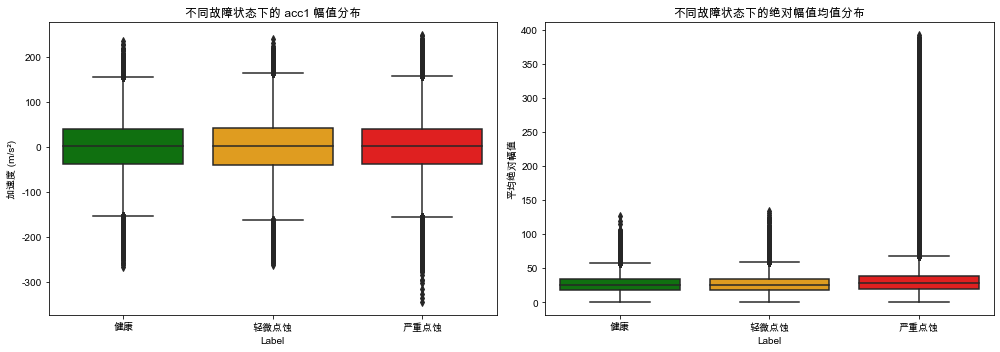


按标签分组的 acc1 统计特征:
             均值        标准差        偏度        峰度
Label                                         
0      0.011723  58.067974 -0.095424  0.053869
1     -0.001407  61.051146 -0.094533 -0.036742
2     -0.022016  59.297301 -0.136994  0.201225


In [19]:
# 绘制不同故障状态下的加速度幅值分布（箱线图）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 子图1：原始加速度值分布
sns.boxplot(data=df, x='Label', y='acc1', palette=['green', 'orange', 'red'], ax=axes[0])
axes[0].set_title('不同故障状态下的 acc1 幅值分布')
axes[0].set_xticklabels(['健康', '轻微点蚀', '严重点蚀'])
axes[0].set_ylabel('加速度 (m/s²)')

# 子图2：计算每个样本的绝对幅值均值（一种简单的冲击指标）
df['abs_mean'] = df[['acc1','acc2','acc3','acc4']].abs().mean(axis=1)
sns.boxplot(data=df, x='Label', y='abs_mean', palette=['green', 'orange', 'red'], ax=axes[1])
axes[1].set_title('不同故障状态下的绝对幅值均值分布')
axes[1].set_xticklabels(['健康', '轻微点蚀', '严重点蚀'])
axes[1].set_ylabel('平均绝对幅值')

plt.tight_layout()
plt.show()

print("\n按标签分组的 acc1 统计特征:")
stats_df = df.groupby('Label')['acc1'].agg([
    ('均值', 'mean'),
    ('标准差', 'std'),
    ('偏度', skew),
    ('峰度', kurtosis)
])
print(stats_df)

## 传感器相关性分析

看看4个加速度计之间的数据是否高度相关。

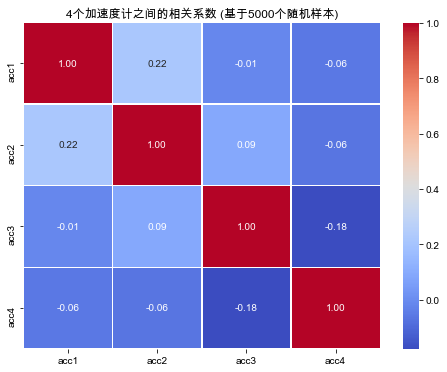

In [25]:
# 随机抽取 5000 行计算相关矩阵（全量计算也很快）
corr_df = df[['acc1', 'acc2', 'acc3', 'acc4']].sample(5000, random_state=42)
corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('4个加速度计之间的相关系数 (基于5000个随机样本)')
plt.show()